## SMOTE(Synthetic Minority Oversampling Technique)
SMOTE (Synthetic Minority Over-sampling Technique) is a technique used in machine learning to address imbalanced datasets where the minority class has significantly fewer instances than the majority class. SMOTE involves generating synthetic instances of the minority class by interpolating between existing instances.

In [1]:
from sklearn.datasets import make_classification

In [ ]:
# make_classification to create a synthetic imbalanced dataset
# weights parameter to specify the proportion of each class
# n_features is total number of features except target
# X is feature set, y is target variable
# target variables values will be 0 and 1 because by default make_classification creates binary classification dataset
X,y=make_classification(n_samples=1000,n_redundant=0,n_features=2,n_clusters_per_class=1,
                   weights=[0.90],random_state=12)

In [ ]:
import pandas as pd
# X is 2D array with 1000 rows and 2 columns
# y is 1D array with 1000 rows
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
final_df=pd.concat([df1,df2],axis=1) # axis=1 to concat columns-wise, if rows do not match then it will fill with NaN
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [6]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

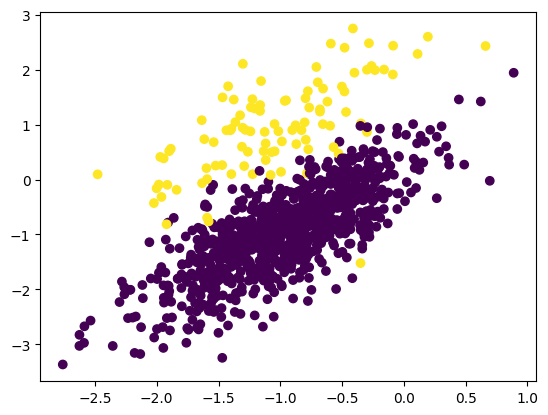

In [15]:
import matplotlib.pyplot as plt
# x axis is f1, y axis is f2, color is target variable
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target']) # c is for color

In [7]:
!pip install imblearn


   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-l

In [8]:
from imblearn.over_sampling import SMOTE

In [ ]:
## transform the dataset
# smote will create synthetic samples for minority class to balance the dataset
# the algorithm works by selecting examples that are close in the feature space, drawing a line between the examples in the feature space, and creating new samples at points along that line.
# instead of final_df[['f1','f2']], we can also use final_df.drop('target',axis=1) to drop target column and use rest of the columns as features
oversample=SMOTE()
X,y=oversample.fit_resample(final_df[['f1','f2']],final_df['target'])

In [11]:
X.shape

(1800, 2)

In [12]:
y.shape

(1800,)

In [18]:
len(y[y==0])

900

In [19]:
len(y[y==1])

900

In [13]:
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
oversample_df=pd.concat([df1,df2],axis=1)

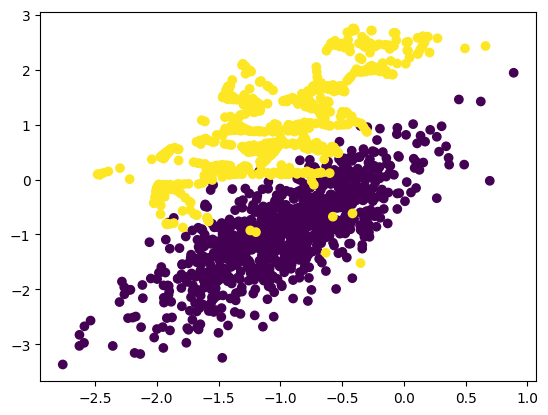

In [16]:
plt.scatter(oversample_df['f1'],oversample_df['f2'],c=oversample_df['target'])